# Notebook 2 — Processing & Analysis

Merges the cleaned datasets, evaluates indicator fill rates, visualises trends, and performs correlation analysis to remove redundant indicators.

**Input:** `data/processed/indicator_data.parquet`, `data/processed/indicator_values.parquet`  
**Output saved to `data/processed/`:** `consolidated_table.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pycountry
import os

pd.set_option('display.max_columns', None)

# Find data directory (works from project root or notebooks/)
if os.path.isdir('data'):
    drive_data_path = os.path.abspath('data')
elif os.path.isdir('../data'):
    drive_data_path = os.path.abspath('../data')
else:
    raise FileNotFoundError('Cannot find data directory')

outputs_path = os.path.join(os.path.dirname(drive_data_path), 'outputs')
processed_path = os.path.join(drive_data_path, 'processed')
os.makedirs(processed_path, exist_ok=True)

os.chdir(drive_data_path)

In [2]:
# Load processed data from Notebook 1
indicator_data = pd.read_parquet(os.path.join(processed_path, 'indicator_data.parquet'))
indicator_values = pd.read_parquet(os.path.join(processed_path, 'indicator_values.parquet'))
print(f'indicator_data: {indicator_data.shape}')
print(f'indicator_values: {indicator_values.shape}')

indicator_data: (18, 2)
indicator_values: (787975, 19)


---

# Analysis of Consolidated Data

The following sections merge, filter, and transform the datasets to produce a final **Education Potential Score** for each country.

## Processing 3: Merge and Select Indicators

Combine data from all retained tables:
- **Merge key**: `Indicator Code` (linking `indicator_values` with `indicator_data`)
- Only matching indicators are kept (inner join)

In [3]:
# Merge indicator values with indicator descriptions
consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',
    right_on='Series Code',
    how='inner'
)

# Clean up duplicate columns from merge
consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

# Keep only relevant columns
year_columns = [str(y) for y in range(2010, 2025)]
consolidated_table = consolidated_table[
    ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + year_columns
]

print(f'Shape: {consolidated_table.shape}')
consolidated_table.head()

Shape: (3870, 19)


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,4.743679e+01,5.062723e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,3.133262e+01,3.241703e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,GDP at market prices (constant 2005 US$),NY.GDP.MKTP.KD,1.593680e+10,1.691113e+10,1.935220e+10,1.973134e+10,1.999032e+10,2.021272e+10,2.066392e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Processing 4: Fill Rate Evaluation

Evaluate the **fill rate** (proportion of non-null values) for each indicator across the 2010Ã¢â‚¬â€œ2024 period. Indicators with poor data coverage will be identified and potentially excluded.

The 9 indicators retained for further analysis cover education enrolment, government expenditure, GDP, and internet access.

In [4]:
columns_to_check = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------
# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')


# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)


Ranked fill rate per column:
 2010    1.0
2011    2.0
2012    3.0
2013    4.0
2014    5.0
2015    6.0
2016    7.0
2017    9.0
2018    9.0
2019    9.0
2020    8.0
2021    9.0
2022    9.0
2023    9.0
2024    9.0
dtype: float64


In [5]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
print(f'Shape after indicator selection: {consolidated_table.shape}')
consolidated_table.head()

Shape after indicator selection: (1720, 19)


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Processing 5: Indicator Trend Visualisation (2010Ã¢â‚¬â€œ2015)

Visualise the **average evolution** of each retained indicator over time (2010Ã¢â‚¬â€œ2015). This helps identify trends, data gaps, and indicators that are stable vs. volatile.

The data is melted from wide format (year columns) to long format, then grouped by indicator and year to compute the mean value across all countries.

In [6]:
# Melt the consolidated table to long format
# Assuming consolidated_table still contains year columns 2010-2024 before the final pivot
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Explicitly melt year columns
)

# Convert Year to numeric
melted_consolidated_table['Year'] = pd.to_numeric(melted_consolidated_table['Year'])

# Filter for years 2010 to 2015
melted_consolidated_table_filtered = melted_consolidated_table[
    (melted_consolidated_table['Year'] >= 2010) & (melted_consolidated_table['Year'] <= 2015)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Calculate the average indicator value per year across countries where data is available
average_indicator_evolution = melted_consolidated_table_filtered.groupby(['Indicator Name', 'Year'])['Value'].mean().reset_index()

# Get unique indicator names
unique_indicators = average_indicator_evolution['Indicator Name'].unique()

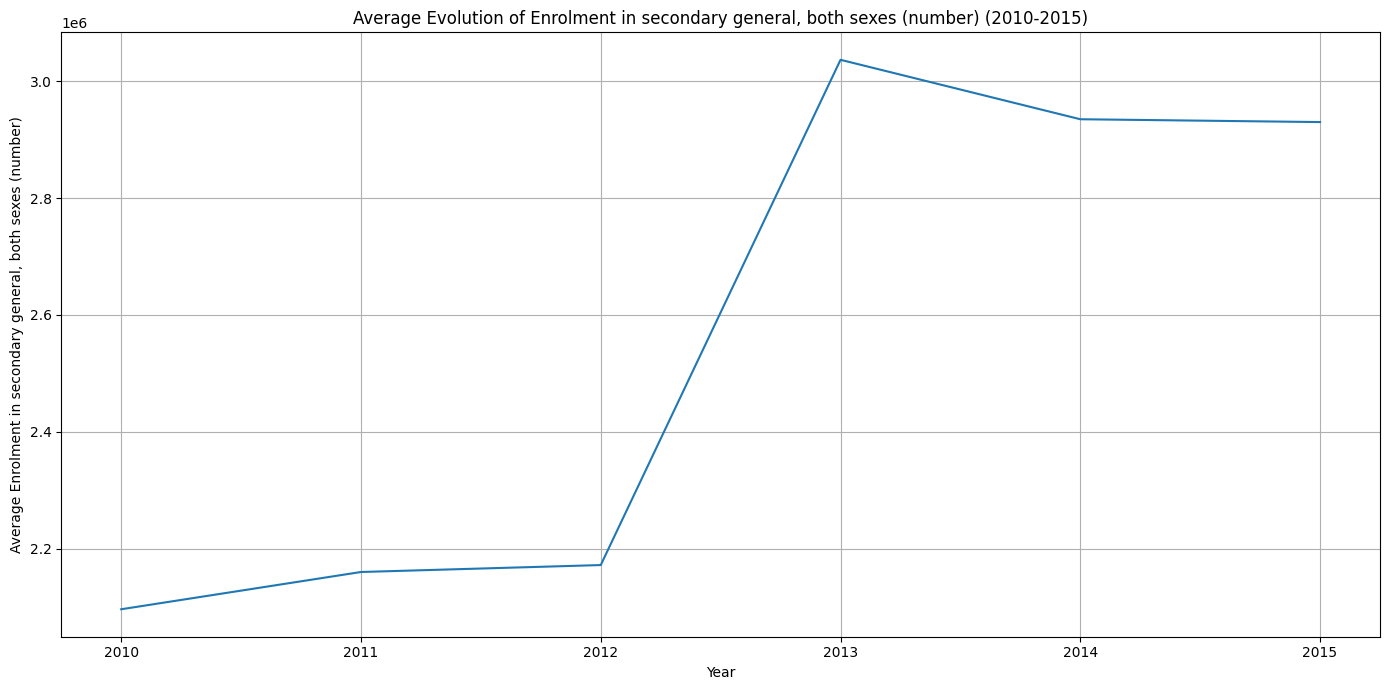

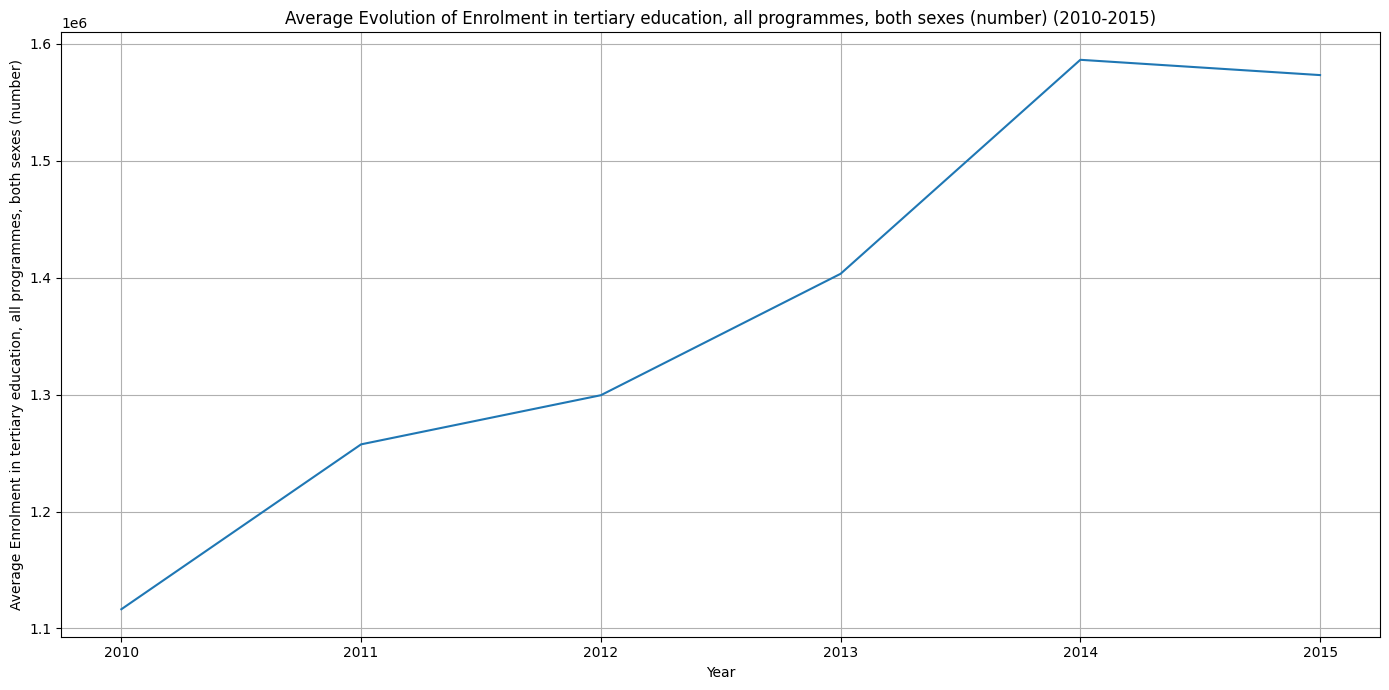

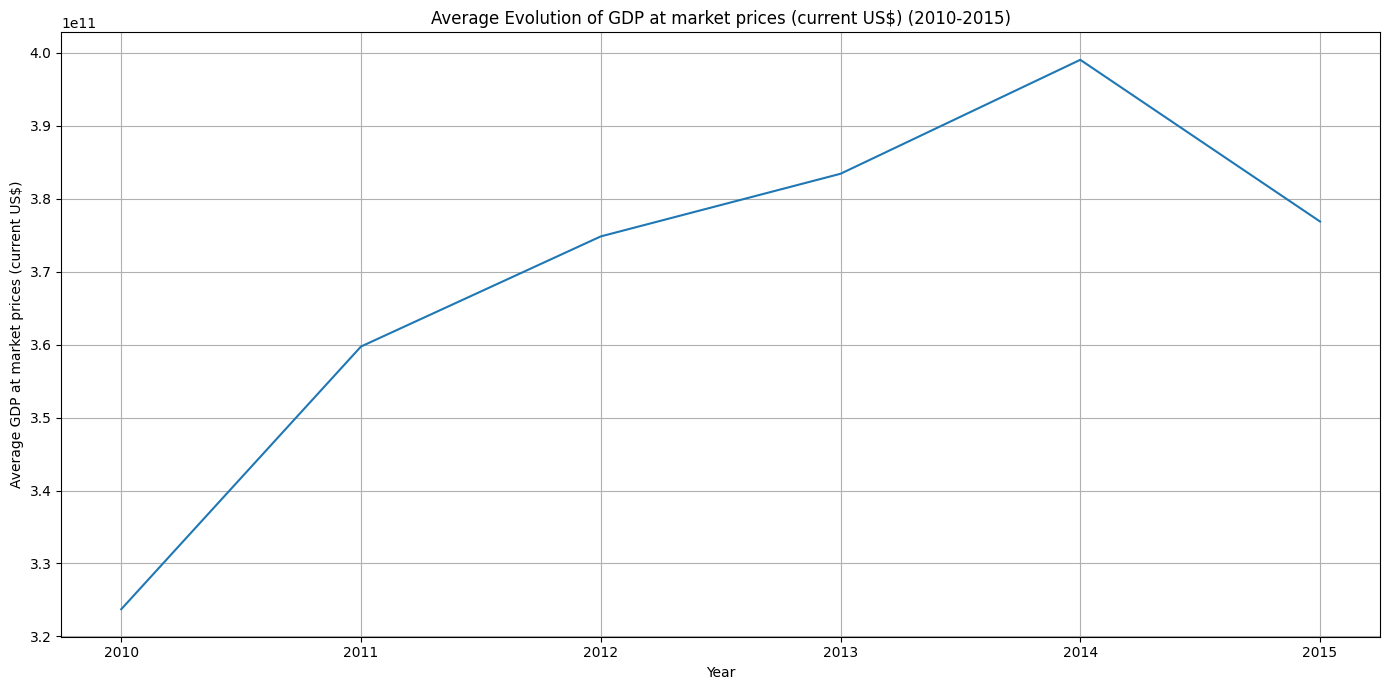

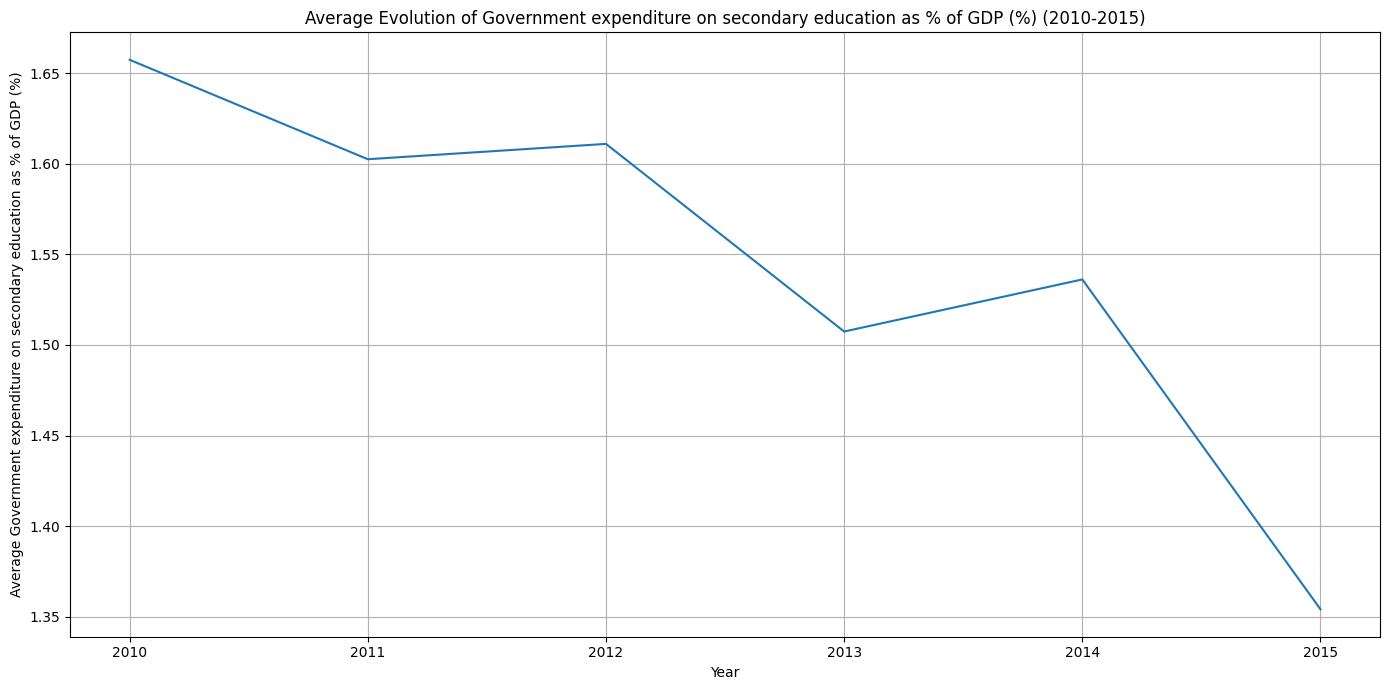

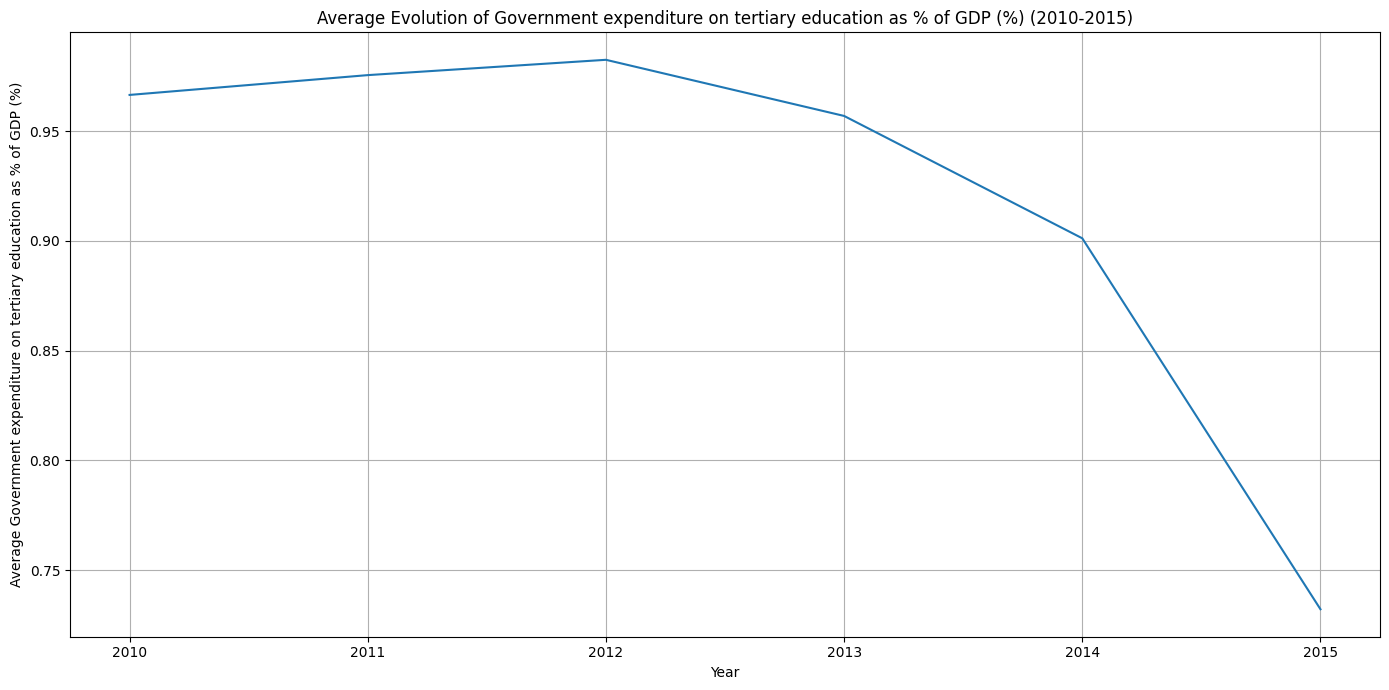

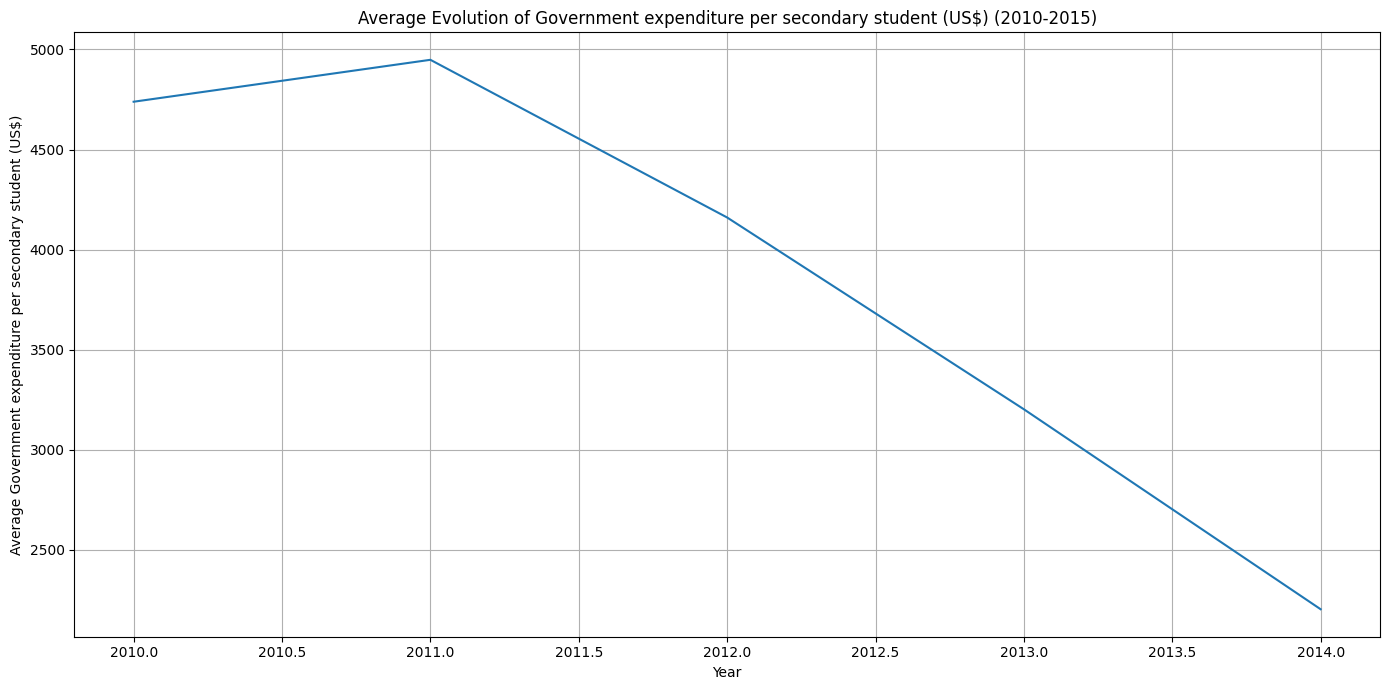

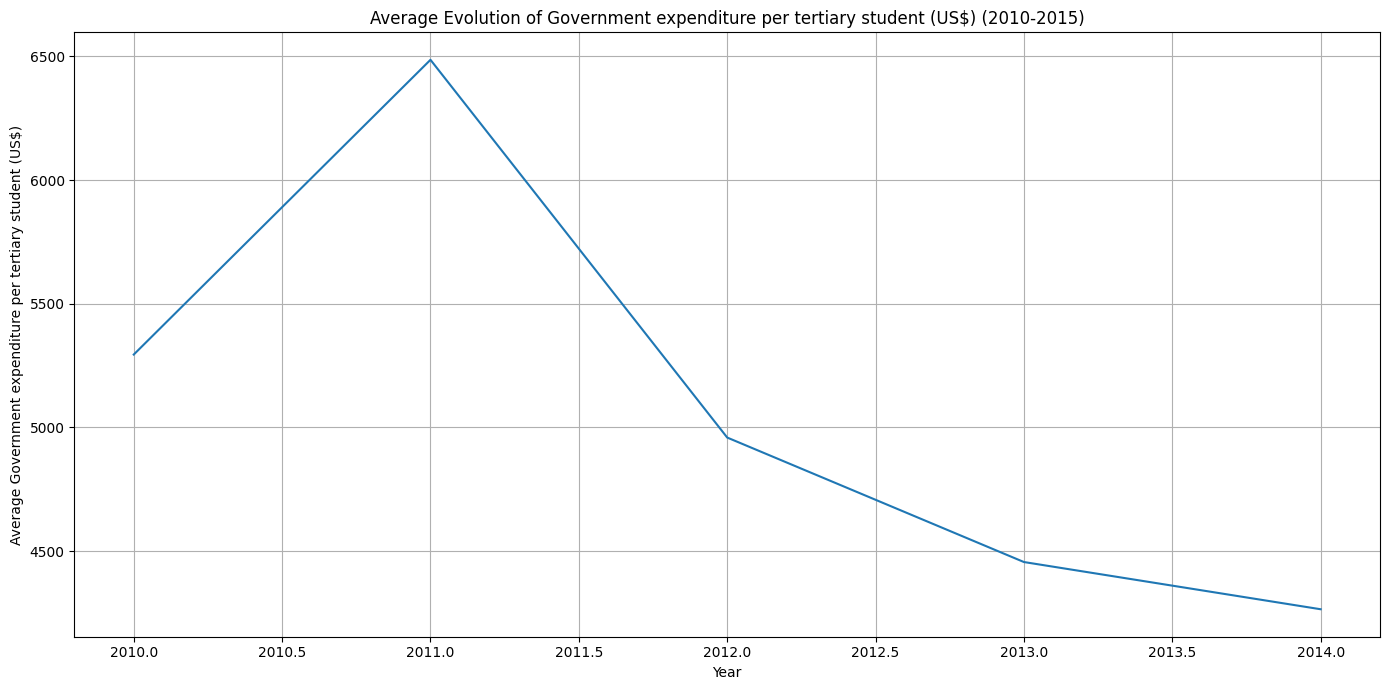

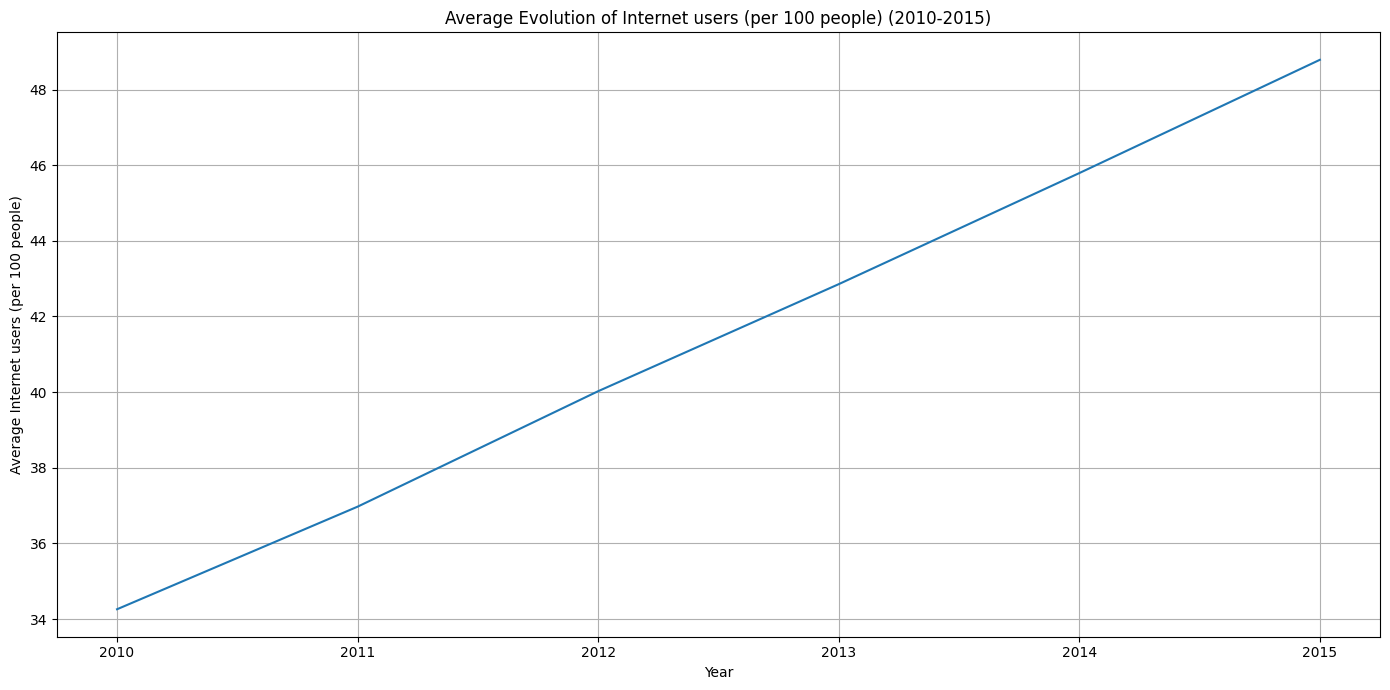

In [7]:
def plot_indicator_trend(data, indicator_name):
    """Plot average evolution of an indicator over 2010-2015."""
    indicator_data = data[data['Indicator Name'] == indicator_name]
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=indicator_data, x='Year', y='Value')
    plt.title(f'Average Evolution of {indicator_name} (2010-2015)')
    plt.xlabel('Year')
    plt.ylabel(f'Average {indicator_name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for indicator_name in unique_indicators:
    plot_indicator_trend(average_indicator_evolution, indicator_name)

## Processing 6: Correlation Analysis

Compute the **Pearson correlation matrix** between all retained indicators to identify redundant or highly correlated variables.

Steps:
1. Melt and pivot the data to create a matrix of indicator values per country and year
2. Compute pairwise correlations
3. Flatten the correlation matrix and enrich with indicator descriptions

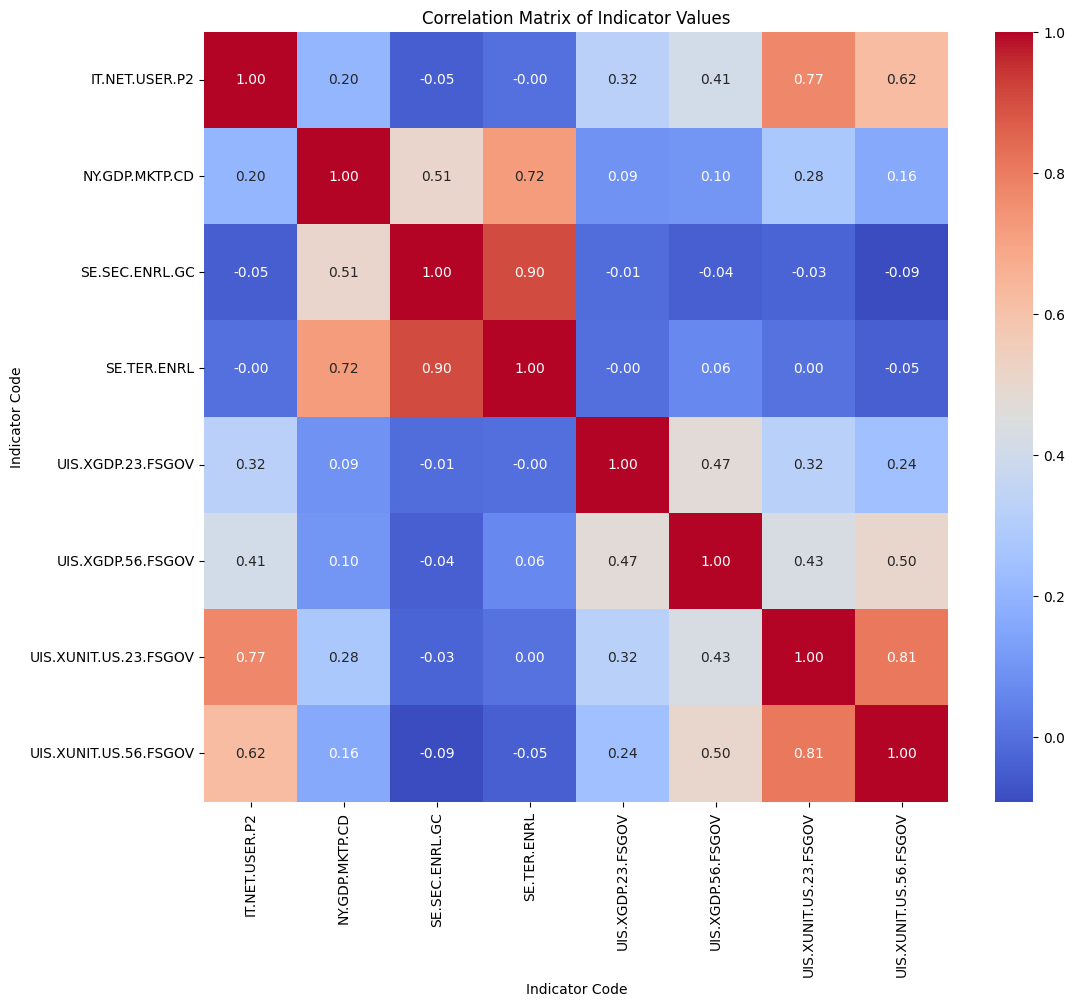

In [8]:
# make the table to perform correlation analysis

correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name", "Indicator Code", "Indicator Name"],
    value_vars=[ '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
# Drop rows with any NaN values
correlation_data.dropna(how='any', inplace=True)

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()


# prepare a correlation matrix

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()


In [9]:
# Flatten correlation matrix (lower triangle only)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
stacked_corr = corr_matrix.where(mask).stack()
stacked_corr.index.set_names(['Indicator_1', 'Indicator_2'], inplace=True)
corr_flat_table_simple = stacked_corr.reset_index()
corr_flat_table_simple.columns = ['Indicator_1', 'Indicator_2', 'Correlation']
corr_flat_table_simple['Absolute Correlation'] = corr_flat_table_simple['Correlation'].abs()
corr_flat_table_simple = corr_flat_table_simple.sort_values(by='Absolute Correlation', ascending=False).drop(columns='Absolute Correlation')

# Enrich with indicator descriptions
corr_flat_table_simple = pd.merge(
    corr_flat_table_simple, indicator_data,
    left_on='Indicator_1', right_on='Series Code', how='left'
)
corr_flat_table_simple.rename(columns={'Indicator Name': 'Indicator_1_Description'}, inplace=True)
corr_flat_table_simple.drop(columns='Series Code', inplace=True)

corr_flat_table_simple = pd.merge(
    corr_flat_table_simple, indicator_data,
    left_on='Indicator_2', right_on='Series Code', how='left'
)
corr_flat_table_simple.rename(columns={'Indicator Name': 'Indicator_2_Description'}, inplace=True)
corr_flat_table_simple.drop(columns='Series Code', inplace=True)

corr_flat_table_simple = corr_flat_table_simple[
    ['Indicator_1', 'Indicator_2', 'Correlation', 'Indicator_1_Description', 'Indicator_2_Description']
]
display(corr_flat_table_simple.head())

,Indicator_1,Indicator_2,Correlation,Indicator_1_Description,Indicator_2_Description
0,SE.SEC.ENRL.GC,SE.TER.ENRL,0.904368,"Enrolment in secondary general, both sexes (nu...","Enrolment in tertiary education, all programme..."
1,UIS.XUNIT.US.23.FSGOV,UIS.XUNIT.US.56.FSGOV,0.810305,Government expenditure per secondary student (...,Government expenditure per tertiary student (US$)
2,IT.NET.USER.P2,UIS.XUNIT.US.23.FSGOV,0.771411,Internet users (per 100 people),Government expenditure per secondary student (...
3,NY.GDP.MKTP.CD,SE.TER.ENRL,0.720190,GDP (current US$),"Enrolment in tertiary education, all programme..."
4,IT.NET.USER.P2,UIS.XUNIT.US.56.FSGOV,0.622931,Internet users (per 100 people),Government expenditure per tertiary student (US$)


## Save Consolidated Table

Persist the processed table to `data/processed/` for Notebook 3.

In [10]:
consolidated_table.to_parquet(os.path.join(processed_path, 'consolidated_table.parquet'), index=False)
print('Saved consolidated_table to data/processed/')

Saved consolidated_table to data/processed/
